In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder

train_transaction = pd.read_csv('ieee-fraud-detection/train_transaction.csv')
train_identity    = pd.read_csv('ieee-fraud-detection/train_identity.csv')
test_transaction  = pd.read_csv('ieee-fraud-detection/test_transaction.csv')
test_identity     = pd.read_csv('ieee-fraud-detection/test_identity.csv')

train = train_transaction.merge(train_identity, on='TransactionID', how='left')
test  = test_transaction.merge(test_identity,  on='TransactionID', how='left')
test.columns = test.columns.str.replace('-', '_')

split = train['TransactionDT'].quantile(0.80)
tr  = train[train['TransactionDT'] <= split].copy()
val = train[train['TransactionDT'] >  split].copy()
print(f"tr {tr.shape} | val {val.shape} | test {test.shape}")

tr (472432, 434) | val (118108, 434) | test (506691, 433)


### Feature definition

In [2]:
delete_cols = ['id_29','V191','V196','V28','V241','V107','V117','V119','V120',
               'V113','V305','V88','V89','V27','V41','V65','V325','V327','V68','id_16','id_27']

cat_fea = ['ProductCD','card1','card2','card3','card4','card5','card6',
           'addr1','addr2','P_emaildomain','R_emaildomain','DeviceType','DeviceInfo']

for i in range(1, 10):
    if 'M'+str(i) not in delete_cols:
        cat_fea.append('M'+str(i))
for i in range(12, 39):
    if 'id_'+str(i) not in delete_cols:
        cat_fea.append('id_'+str(i))

num_fea = [f for f in train.columns
           if f not in ['TransactionID','isFraud'] + cat_fea + delete_cols]

### TransactionDT & TransactionAmt features

In [3]:
for df in [tr, val, test]:
    df['hour']          = (df['TransactionDT'] // 3600) % 24
    df['dayofweek']     = (df['TransactionDT'] // 86400) % 7
    df['day']           = df['TransactionDT']  // 86400
    df['hour_sin']      = np.sin(2 * np.pi * df['hour']      / 24)
    df['hour_cos']      = np.cos(2 * np.pi * df['hour']      / 24)
    df['dayofweek_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
    df['dayofweek_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7)

    df['log_amt']        = np.log1p(df['TransactionAmt'])
    df['amt_decimal']    = (df['TransactionAmt'] % 1).round(2).astype('category')
    df['amt_is_round']   = (df['TransactionAmt'] % 1 == 0).astype(np.int8)
    df['amt_last_digit'] = pd.Series(np.where(
        df['TransactionAmt'] % 1 == 0,
        df['TransactionAmt'].astype(int) % 10, -1
    ), index=df.index).astype('category')

num_fea.extend(['hour','dayofweek','day','hour_sin','hour_cos',
                'dayofweek_sin','dayofweek_cos','log_amt','amt_is_round'])
cat_fea.extend(['amt_decimal','amt_last_digit'])

### Log transform high-skew numeric features (|skew| > 10)

In [4]:
# skew_series = tr[num_fea].select_dtypes(include=[np.number]).skew()
# high_skew_cols = skew_series[skew_series.abs() > 10].index.tolist()
# print(f"Log transforming {len(high_skew_cols)} features")
high_skew_cols = ['C3','V335','id_04']  #after validation

for col in high_skew_cols:
    for df in [tr, val, test]:
        df[col + '_log'] = np.log1p(df[col].clip(lower=0))
    num_fea.append(col + '_log')

### Bin D15

In [5]:
_, bin_edges = pd.qcut(tr['D15'], q=10, retbins=True, duplicates='drop')
for df in [tr, val, test]:
    df['D15_bin'] = pd.cut(df['D15'], bins=bin_edges, labels=False,
                           include_lowest=True).astype('category')
cat_fea.append('D15_bin')
print(f"D15 binned. Total so far — numeric: {len(num_fea)} | categorical: {len(cat_fea)}")

D15 binned. Total so far — numeric: 377 | categorical: 49


### Sort by TransactionDT

In [21]:
tr_s   = tr
val_s  = val
test_s = test

for df in [tr_s, val_s, test_s]:
    df['D1_norm'] = (df['TransactionDT'] // 86400).astype(int) - df['D1']
    df['user_id1'] = df['card1'].astype(str) + '_' + df['addr1'].astype(str) + '_'+ df['D1_norm'].astype(str)
    df['user_id2'] = df['card1'].astype(str) + '_' + df['card2'].astype(str) 
    df['user_id3'] = df['card1'].astype(str) + '_' + df['addr1'].astype(str) 
    df['user_id4'] = df['card1'].astype(str) + '_' + df['addr1'].astype(str) + '_' + df['P_emaildomain'].astype(str) 


# base_df for test aggregations: all labeled data (train + val)
test_base = pd.concat([tr_s, val_s,test_s], ignore_index=True)

cat_fea = ['ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2',
           'P_emaildomain', 'R_emaildomain', 'DeviceType', 'DeviceInfo', 'M1', 'M2', 'M3', 'M4',
           'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_13', 'id_14', 'id_15', 'id_17', 'id_18',
           'id_19', 'id_20', 'id_21', 'id_22', 'id_23', 'id_24', 'id_25', 'id_26', 'id_28',
           'id_30', 'id_31', 'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38',
           'amt_decimal', 'amt_last_digit', 'D15_bin']
#num_fea = ['TransactionDT', 'TransactionAmt', 'dist1', 'dist2', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52', 'V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'V61', 'V62', 'V63', 'V64', 'V66', 'V67', 'V69', 'V70', 'V71', 'V72', 'V73', 'V74', 'V75', 'V76', 'V77', 'V78', 'V79', 'V80', 'V81', 'V82', 'V83', 'V84', 'V85', 'V86', 'V87', 'V90', 'V91', 'V92', 'V93', 'V94', 'V95', 'V96', 'V97', 'V98', 'V99', 'V100', 'V101', 'V102', 'V103', 'V104', 'V105', 'V106', 'V108', 'V109', 'V110', 'V111', 'V112', 'V114', 'V115', 'V116', 'V118', 'V121', 'V122', 'V123', 'V124', 'V125', 'V126', 'V127', 'V128', 'V129', 'V130', 'V131', 'V132', 'V133', 'V134', 'V135', 'V136', 'V137', 'V138', 'V139', 'V140', 'V141', 'V142', 'V143', 'V144', 'V145', 'V146', 'V147', 'V148', 'V149', 'V150', 'V151', 'V152', 'V153', 'V154', 'V155', 'V156', 'V157', 'V158', 'V159', 'V160', 'V161', 'V162', 'V163', 'V164', 'V165', 'V166', 'V167', 'V168', 'V169', 'V170', 'V171', 'V172', 'V173', 'V174', 'V175', 'V176', 'V177', 'V178', 'V179', 'V180', 'V181', 'V182', 'V183', 'V184', 'V185', 'V186', 'V187', 'V188', 'V189', 'V190', 'V192', 'V193', 'V194', 'V195', 'V197', 'V198', 'V199', 'V200', 'V201', 'V202', 'V203', 'V204', 'V205', 'V206', 'V207', 'V208', 'V209', 'V210', 'V211', 'V212', 'V213', 'V214', 'V215', 'V216', 'V217', 'V218', 'V219', 'V220', 'V221', 'V222', 'V223', 'V224', 'V225', 'V226', 'V227', 'V228', 'V229', 'V230', 'V231', 'V232', 'V233', 'V234', 'V235', 'V236', 'V237', 'V238', 'V239', 'V240', 'V242', 'V243', 'V244', 'V245', 'V246', 'V247', 'V248', 'V249', 'V250', 'V251', 'V252', 'V253', 'V254', 'V255', 'V256', 'V257', 'V258', 'V259', 'V260', 'V261', 'V262', 'V263', 'V264', 'V265', 'V266', 'V267', 'V268', 'V269', 'V270', 'V271', 'V272', 'V273', 'V274', 'V275', 'V276', 'V277', 'V278', 'V279', 'V280', 'V281', 'V282', 'V283', 'V284', 'V285', 'V286', 'V287', 'V288', 'V289', 'V290', 'V291', 'V292', 'V293', 'V294', 'V295', 'V296', 'V297', 'V298', 'V299', 'V300', 'V301', 'V302', 'V303', 'V304', 'V306', 'V307', 'V308', 'V309', 'V310', 'V311', 'V312', 'V313', 'V314', 'V315', 'V316', 'V317', 'V318', 'V319', 'V320', 'V321', 'V322', 'V323', 'V324', 'V326', 'V328', 'V329', 'V330', 'V331', 'V332', 'V333', 'V334', 'V335', 'V336', 'V337', 'V338', 'V339', 'id_01', 'id_02', 'id_03', 'id_04', 'id_05', 'id_06', 'id_07', 'id_08', 'id_09', 'id_10', 'id_11', 'hour', 'dayofweek', 'day', 'hour_sin', 'hour_cos', 'dayofweek_sin', 'dayofweek_cos', 'log_amt', 'amt_is_round', 'TransactionAmt_log', 'C1_log', 'C2_log', 'C3_log', 'C4_log', 'C6_log', 'C7_log', 'C8_log', 'C10_log', 'C11_log', 'C12_log', 'C14_log', 'V1_log', 'V14_log', 'V23_log', 'V37_log', 'V38_log', 'V44_log', 'V45_log', 'V47_log', 'V55_log', 'V56_log', 'V77_log', 'V78_log', 'V86_log', 'V87_log', 'V96_log', 'V99_log', 'V100_log', 'V101_log', 'V102_log', 'V103_log', 'V104_log', 'V105_log', 'V106_log', 'V108_log', 'V109_log', 'V110_log', 'V111_log', 'V112_log', 'V114_log', 'V116_log', 'V118_log', 'V121_log', 'V122_log', 'V123_log', 'V125_log', 'V126_log', 'V127_log', 'V128_log', 'V129_log', 'V130_log', 'V131_log', 'V132_log', 'V133_log', 'V134_log', 'V135_log', 'V136_log', 'V137_log', 'V138_log', 'V142_log', 'V161_log', 'V162_log', 'V163_log', 'V166_log', 'V167_log', 'V168_log', 'V172_log', 'V176_log', 'V177_log', 'V178_log', 'V179_log', 'V180_log', 'V182_log', 'V183_log', 'V186_log', 'V187_log', 'V190_log', 'V192_log', 'V193_log', 'V198_log', 'V199_log', 'V200_log', 'V201_log', 'V202_log', 'V203_log', 'V204_log', 'V205_log', 'V206_log', 'V207_log', 'V208_log', 'V209_log', 'V210_log', 'V211_log', 'V212_log', 'V213_log', 'V214_log', 'V215_log', 'V216_log', 'V218_log', 'V219_log', 'V220_log', 'V221_log', 'V222_log', 'V223_log', 'V224_log', 'V225_log', 'V226_log', 'V227_log', 'V228_log', 'V229_log', 'V230_log', 'V231_log', 'V232_log', 'V236_log', 'V240_log', 'V242_log', 'V243_log', 'V244_log', 'V245_log', 'V246_log', 'V247_log', 'V248_log', 'V249_log', 'V252_log', 'V253_log', 'V254_log', 'V255_log', 'V256_log', 'V257_log', 'V258_log', 'V259_log', 'V261_log', 'V262_log', 'V263_log', 'V264_log', 'V265_log', 'V266_log', 'V267_log', 'V268_log', 'V269_log', 'V270_log', 'V271_log', 'V272_log', 'V273_log', 'V274_log', 'V275_log', 'V276_log', 'V277_log', 'V278_log', 'V279_log', 'V280_log', 'V283_log', 'V285_log', 'V287_log', 'V290_log', 'V291_log', 'V292_log', 'V293_log', 'V294_log', 'V295_log', 'V296_log', 'V297_log', 'V298_log', 'V299_log', 'V300_log', 'V301_log', 'V306_log', 'V307_log', 'V308_log', 'V309_log', 'V310_log', 'V311_log', 'V312_log', 'V313_log', 'V314_log', 'V315_log', 'V316_log', 'V317_log', 'V318_log', 'V319_log', 'V320_log', 'V321_log', 'V329_log', 'V331_log', 'V332_log', 'V333_log', 'V334_log', 'V335_log', 'V336_log', 'V337_log', 'V338_log', 'V339_log', 'id_04_log', 'id_10_log']

cat_fea.extend(['user_id1','user_id3'])


In [22]:
# train['P_email_suffix'] = train['P_emaildomain'].str.split('.').str[-1]
# train['R_email_suffix'] = train['R_emaildomain'].str.split('.').str[-1]


# # normalise D columns against TransactionDT
# for col in ['D1', 'D2', 'D3', 'D4', 'D5']:
#     train[col + '_norm'] = train['TransactionDT'] - train[col] * 86400

# # amount vs customer average — key fraud signal
# tr['amt_vs_uid_mean'] = tr['TransactionAmt'] / (tr['uid1_mean_amt'] + 1e-5)

# # log version — more stable
# tr['amt_vs_uid_mean_log'] = np.log1p(tr['TransactionAmt']) - np.log1p(tr['uid1_mean_amt'])

### groupby_agg_features

Computes per-entity aggregate statistics from `base_df` and merges them into `target_df`.

- `base_df`  — source of aggregation (tr_s for train/val; test_base for test)
- `target_df` — DataFrame to add features to (modified in-place)
- `col`      — groupby key (entity column)
- `valueset` — non-empty list of numeric columns to aggregate

For each value column, 8 stats are added: `cnt`, `sum`, `avg`, `min`, `max`, `p25`, `p50`, `p75`.

In [23]:
def groupby_agg_features(base_df, target_df, col, valueset):
    """
    Compute per-entity aggregate stats from base_df and join to target_df.

    valueset : non-empty list of numeric columns to aggregate.
    Modifies target_df in-place; returns list of new feature names.
    """
    agg_parts = []
    new_feats = []

    for val in valueset:
        g = base_df.groupby(col)[val]
        part = pd.concat([
            g.count()          .rename(f"{col}_{val}_cnt"),
            g.sum()            .rename(f"{col}_{val}_sum"),
            g.mean()           .rename(f"{col}_{val}_avg"),
            g.min()            .rename(f"{col}_{val}_min"),
            g.max()            .rename(f"{col}_{val}_max"),
            g.quantile(0.25)   .rename(f"{col}_{val}_p25"),
            g.median()         .rename(f"{col}_{val}_p50"),
            g.quantile(0.75)   .rename(f"{col}_{val}_p75"),
        ], axis=1)
        agg_parts.append(part)
        new_feats.extend(part.columns.tolist())

    agg_df  = pd.concat(agg_parts, axis=1).reset_index()   # col becomes a regular column
    merged  = target_df[[col]].reset_index().merge(agg_df, on=col, how='left').set_index('index')

    for feat in new_feats:
        target_df[feat] = merged[feat]

    return new_feats


# ── columns to aggregate per entity ──────────────────────────────────────────
n = 256  # unique-value threshold for native category dtype
# ─────────────────────────────────────────────────────────────────────────────

### Categorical encoding + groupby aggregate features

- Unique values < 128  → native LightGBM category dtype
- Unique values ≥ 128  → `groupby_agg_features` on each column in `valueset`

In [24]:
groupby_features = []
for col in list(cat_fea):
    if col in ["card1","card2","addr1","P_emaildomain","card5",'user_id1','user_id3']:
        print(col)
        valueset = ['TransactionAmt','C13','dist1']
        feats = groupby_agg_features(test_base,      tr_s,   col, valueset)
        groupby_agg_features(test_base,      val_s,  col, valueset)
        groupby_agg_features(test_base, test_s, col, valueset)
        groupby_features.extend(feats)
        if col not in ['card5','P_emaildomain']:
            cat_fea.remove(col)
        else:
            tr_cats = tr_s[col].astype('category').cat.categories
            for df in [tr_s, val_s, test_s]:
                df[col] = pd.Categorical(df[col], categories=tr_cats)
        print(f"  {col} done — {len(feats)} features")

    else: 
        cur_unique = tr_s[col].nunique()
        if cur_unique < n:
            tr_cats = tr_s[col].astype('category').cat.categories
            for df in [tr_s, val_s, test_s]:
                df[col] = pd.Categorical(df[col], categories=tr_cats)
        else:
            print(col)
            valueset = ['TransactionAmt']
            feats = groupby_agg_features(test_base,      tr_s,   col, valueset)
            groupby_agg_features(test_base,      val_s,  col, valueset)
            groupby_agg_features(test_base , test_s, col, valueset)
            groupby_features.extend(feats)
            cat_fea.remove(col)
            print(f"  {col} done — {len(feats)} features")

card1
  card1 done — 24 features
card2
  card2 done — 24 features
card5
  card5 done — 24 features
addr1
  addr1 done — 24 features
P_emaildomain
  P_emaildomain done — 24 features
DeviceInfo
  DeviceInfo done — 8 features
id_19
  id_19 done — 8 features
id_20
  id_20 done — 8 features
id_21
  id_21 done — 8 features
id_25
  id_25 done — 8 features
user_id1
  user_id1 done — 24 features
user_id3
  user_id3 done — 24 features


In [25]:
features = num_fea + cat_fea + groupby_features 
print(f"Total features: {len(features)} | numeric: {len(num_fea)} | categorical: {len(cat_fea)} | groupby: {len(groupby_features)}")
print(f"Categorical features: {cat_fea}")

Total features: 626 | numeric: 377 | categorical: 41 | groupby: 208
Categorical features: ['ProductCD', 'card3', 'card4', 'card5', 'card6', 'addr2', 'P_emaildomain', 'R_emaildomain', 'DeviceType', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_13', 'id_14', 'id_15', 'id_17', 'id_18', 'id_22', 'id_23', 'id_24', 'id_26', 'id_28', 'id_30', 'id_31', 'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'amt_decimal', 'amt_last_digit', 'D15_bin']


### Train model

In [26]:
X_tr   = tr_s[features].copy()
X_val  = val_s[features].copy()
X_test = test_s[features].copy()
y_tr   = tr_s['isFraud']
y_val  = val_s['isFraud']

model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=256,
    random_state=42,
    n_jobs=-1
)
model.fit(
    X_tr, y_tr,
    eval_set=[(X_tr, y_tr), (X_val, y_val)],
    eval_names=["train", "valid"],
    categorical_feature=cat_fea,
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.185278 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 63686
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 626
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
Training until validation scores don't improve for 50 rounds
[100]	train's binary_logloss: 0.027005	valid's binary_logloss: 0.0790705
[200]	train's binary_logloss: 0.0114633	valid's binary_logloss: 0.0784973
Early stopping, best iteration is:
[159]	train's binary_logloss: 0.0158193	valid's binary_logloss: 0.0777795


,boosting_type,'gbdt'
,num_leaves,256
,max_depth,-1
,learning_rate,0.05
,n_estimators,1000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


### Validation performance

In [27]:
val_pred = model.predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, val_pred)
print(f"model_v2 AUC : 0.9257  (label_fre_3, global freq — leaked)")
print(f"model_v3 AUC : 0.9127  (rolling count — leak-free)")
print(f"model_v4 AUC : {auc:.4f} (groupby aggregate)")
print(f"Diff vs v2   : {auc - 0.9257:+.4f}")

model_v2 AUC : 0.9257  (label_fre_3, global freq — leaked)
model_v3 AUC : 0.9127  (rolling count — leak-free)
model_v4 AUC : 0.9390 (groupby aggregate)
Diff vs v2   : +0.0133


### Confusion matrix

Sweep thresholds and report precision / recall / F1 alongside the matrix at the best-F1 threshold.

Best-F1 threshold : 0.2846  | precision 0.7080  recall 0.5244  F1 0.6025
thr=0.1000 | precision=0.4733 recall=0.6489 F1=0.5474
thr=0.2000 | precision=0.6234 recall=0.5657 F1=0.5931
thr=0.3000 | precision=0.7167 recall=0.5155 F1=0.5997
thr=0.5000 | precision=0.8284 recall=0.4382 F1=0.5732
thr=0.2846 | precision=0.7080 recall=0.5244 F1=0.6025

Confusion matrix @ thr=0.2846
            pred_neg  pred_pos
actual_neg    113165       879
actual_pos      1933      2131

TN=113165  FP=879  FN=1933  TP=2131
Fraud catch rate (recall) : 0.5244
False-alarm rate          : 0.0077


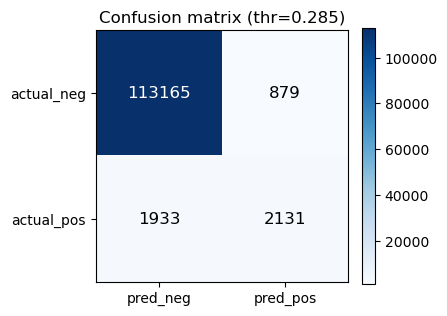

In [497]:
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, precision_recall_curve
import matplotlib.pyplot as plt

prec, rec, thr = precision_recall_curve(y_val, val_pred)
f1 = 2 * prec * rec / (prec + rec + 1e-12)
best_idx = f1[:-1].argmax()
best_thr = thr[best_idx]
print(f"Best-F1 threshold : {best_thr:.4f}  | precision {prec[best_idx]:.4f}  recall {rec[best_idx]:.4f}  F1 {f1[best_idx]:.4f}")

for t in [0.1, 0.2, 0.3, 0.5, best_thr]:
    y_hat = (val_pred >= t).astype(int)
    p, r, f, _ = precision_recall_fscore_support(y_val, y_hat, average='binary', zero_division=0)
    print(f"thr={t:.4f} | precision={p:.4f} recall={r:.4f} F1={f:.4f}")

y_hat = (val_pred >= best_thr).astype(int)
cm = confusion_matrix(y_val, y_hat)
tn, fp, fn, tp = cm.ravel()
print(f"\nConfusion matrix @ thr={best_thr:.4f}")
print(pd.DataFrame(cm,
                   index=['actual_neg','actual_pos'],
                   columns=['pred_neg','pred_pos']))
print(f"\nTN={tn}  FP={fp}  FN={fn}  TP={tp}")
print(f"Fraud catch rate (recall) : {tp/(tp+fn):.4f}")
print(f"False-alarm rate          : {fp/(fp+tn):.4f}")

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm, cmap='Blues')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=12)
ax.set_xticks([0, 1]); ax.set_xticklabels(['pred_neg', 'pred_pos'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['actual_neg', 'actual_pos'])
ax.set_title(f'Confusion matrix (thr={best_thr:.3f})')
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

### Feature importance

In [533]:
importance = (pd.DataFrame({
    'feature':    features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True))

print("=== Top 40 ===")
print(importance.head(40).to_string(index=False))

print("\n=== compare engineered features ===")
print(importance[importance['feature'].isin(new_feats)].to_string(index=False))

print(importance[importance['feature'].isin(['TransactionAmt'])].to_string(index=False))

=== Top 40 ===
                    feature  importance
                amt_decimal        1980
user_id1_TransactionAmt_sum         549
              TransactionDT         538
user_id1_TransactionAmt_max         526
                      id_31         500
           user_id1_C13_max         412
           user_id1_C13_sum         398
user_id1_TransactionAmt_min         385
user_id1_TransactionAmt_p25         354
             TransactionAmt         342
user_id3_TransactionAmt_max         327
                        D15         312
user_id1_TransactionAmt_avg         310
   card2_TransactionAmt_max         308
                         C1         303
         user_id3_dist1_max         302
user_id3_TransactionAmt_avg         294
user_id1_TransactionAmt_p50         292
           user_id1_C13_avg         287
         user_id3_dist1_avg         286
         user_id3_dist1_p75         285
user_id1_TransactionAmt_p75         280
              card1_C13_avg         272
              P_emaildoma

### Generate submission

In [319]:
test_pred = model.predict_proba(X_test)[:, 1]

submission = pd.DataFrame({
    'TransactionID': test_s['TransactionID'].values,
    'isFraud':       test_pred
})

test_original_order = test_transaction['TransactionID'].values
submission = submission.set_index('TransactionID').loc[test_original_order].reset_index()

submission.to_csv('submission_with_uid_comb.csv', index=False)
print(f"Saved: {submission.shape}")
print(submission['isFraud'].describe().round(4))

Saved: (506691, 2)
count    506691.0000
mean          0.0280
std           0.1176
min           0.0002
25%           0.0015
50%           0.0032
75%           0.0086
max           0.9980
Name: isFraud, dtype: float64
